# Building with LangGraph

## Building a ChatBot

In [3]:
pip install --upgrade -q openai langchain langchain-openai langchain-community langgraph langgraph-checkpoint-sqlite

Note: you may need to restart the kernel to use updated packages.


In [2]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic.v1.fields import FieldInfo as FieldInfoV1

In [3]:
# loading the API key from .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)

# defining the chatbot node
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# adding the node to the graph
graph_builder.add_node("chatbot", chatbot)

# setting the entry and the finish points
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

## Visualizing the Graph

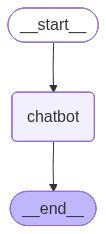

In [5]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
pip install -q grandalf

Note: you may need to restart the kernel to use updated packages.


In [6]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


## Running the ChatBot

In [7]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye', 'q']:
        print('Goodbye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print(f'Assistant: {value["messages"][-1].content}')
            print('-' * 20)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Assistant: The distance to the Moon is not constant because its orbit around Earth is elliptical.

However, here are the key figures:

*   **On average:** Approximately **238,900 miles** (384,400 kilometers)
*   **At its closest (perigee):** About **221,500 miles** (356,400 kilometers)
*   **At its farthest (apogee):** About **252,700 miles** (406,700 kilometers)

So, a good general answer is **around 239,000 miles**.
--------------------


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Assistant: Leeds is famous for a variety of things, making it a vibrant and diverse city. Here are some of its key claims to fame:

1.  **Shopping:** Often called the "Knightsbridge of the North," Leeds boasts an incredible shopping scene, from high-end luxury brands in the stunning Victorian arcades (like the Victoria Quarter and Grand Arcade) to major high street retailers and independent boutiques.
2.  **Universities and Student Life:** Home to several major universities (University of Leeds, Leeds Beckett University), it has a huge student population, contributing to its vibrant, youthful energy and diverse cultural scene.
3.  **Arts and Culture:** A significant cultural hub, Leeds is home to world-class institutions like Opera North, Northern Ballet, the Leeds Playhouse, and numerous museums and art galleries (e.g., Leeds Art Gallery, Royal Armouries Museum).
4.  **Sport:** Famously home to Leeds United Football Club (Elland Road) and Yorkshire County Cricket Club (Headingley Stad

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Goodbye!


## Tavily AI

In [9]:
pip install -q tavily-python

Note: you may need to restart the kernel to use updated packages.


In [10]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [11]:
from tavily import TavilyClient
import os

# initializing a Tavily client
client = TavilyClient(api_key=os.environ.get('TAVILY_API_KEY'))

response = client.search(query='Germany 2025 elections')
response

{'query': 'Germany 2025 elections',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': '2025 German federal election - Simple English Wikipedia, the free ...',
   'url': 'https://simple.wikipedia.org/wiki/2025_German_federal_election',
   'content': 'Federal elections in Germany will be held on 23 February 2025 to elect the 630 members of the 21st Bundestag.Originally scheduled for 28 September 2025, the elections were brought forward because of the collapse of the governing coalition during the 2024 German government crisis. [1]It is the fourth snap election in the history of post-war Germany after those in 1972, 1983 and 2005.',
   'score': 0.94989765,
   'raw_content': None},
  {'title': '2025 German federal election - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/2025_German_federal_election',
   'content': 'Federal elections in Germany will be held on 28 September 2025 to elect the members of the 21st Bundestag. The law was subject to const

In [12]:
for result in response['results']:
    print(f"Title: {result['title']}, URL: {result['url']}")

Title: 2025 German federal election - Simple English Wikipedia, the free ..., URL: https://simple.wikipedia.org/wiki/2025_German_federal_election
Title: 2025 German federal election - Wikipedia, URL: https://en.wikipedia.org/wiki/2025_German_federal_election
Title: Germany: Polls and trends for the 2025 election, URL: https://politpro.eu/en/germany
Title: German election 2025 - Financial Times, URL: https://www.ft.com/german-election-2025
Title: Who are Germany's top candidates in the 2025 election?, URL: https://www.dw.com/en/who-are-germanys-top-candidates-in-the-2025-election/g-70812286


In [13]:
response = client.search(
    query='What is DeepSeek R1?',
    search_depth='advanced',
    max_results=7,
    include_images=True,
    include_answer=True,
    include_raw_content=False
)
response

{'query': 'What is DeepSeek R1?',
 'follow_up_questions': None,
 'answer': 'DeepSeek R1 is an open-source reasoning large language model developed by Chinese AI lab DeepSeek. It is designed to perform well in tasks such as coding, mathematics, multilingual processing, and reasoning, often outperforming proprietary systems like GPT-4 Omni and Claude 3.5 Sonnet. DeepSeek R1 is notable for its efficiency, being trained with fewer resources and being significantly cheaper to use. It also includes built-in tools for explainable AI, addressing a gap in reinforcement learning models.',
 'images': ['https://www.maginative.com/content/images/size/w1200/2025/01/Deepseek-R1.jpg',
  'https://www.eonmsk.com/wp-content/uploads/2025/01/deepseek-img1-1000x576.jpg',
  'http://finblog.com/wp-content/uploads/2025/01/DeepSeek-944x1024.webp',
  'https://www.jeremymorgan.com/images/blog/tech/what-is-deepseek-r1/what-is-deepseek-r1-04.webp',
  'https://techwiser.com/wp-content/uploads/2025/01/DeepSeek-R1.web

In [15]:
answer = client.qna_search(query='What is Project Stargate?')
print(answer)

The Stargate Project is a $500 billion AI initiative announced by U.S. President Donald Trump in January 2025, led by companies including SoftBank, OpenAI, and Oracle. The project aims to build new AI infrastructure in the United States over the next four years.


In [16]:
from langchain.adapters.openai import convert_openai_messages
from langchain_openai import ChatOpenAI

query = 'Tell me about OpenAI o3 model.'

response = client.search(query, max_results=5, search_depth='advanced')['results']
response

[{'title': "OpenAI's O3: Features, O1 Comparison, Release Date & More",
  'url': 'https://www.datacamp.com/blog/o3-openai',
  'content': "O3 is OpenAI’s latest frontier model, designed to advance reasoning capabilities across a range of complex tasks. OpenAI has positioned o3 as a model designed to handle more complex reasoning tasks, with performance gains reflected in its benchmarks. o3 is the latest iteration of OpenAI's reasoning models. Compared to OpenAI o1, the o3 and o3-mini models demonstrate improved performance in reasoning tasks, including coding, scientific analysis, and breakthrough capabilities to novel tasks. OpenAI o1 is a new series of models from OpenAI excelling in complex reasoning tasks, using chain-of-thought reasoning to outperform GPT-4o in areas like math, coding, and science. Learn about OpenAI’s new ChatGPT Pro subscription plan and its most advanced model, o1 pro mode, featuring enhanced accuracy, reliability, and complex reasoning abilities.",
  'score': 0

In [17]:
# setting up the OpenAI API prompt
prompt = [
    {
        'role': 'system',
        'content': f'''You are an AI critical thinker research assistant. 
        Your sole purpose is to write well written, objective and structured reports on given text.'''
    },
    {
        'role': 'user',
        'content': f'''Information: """{response}"""
        Using the above information, answer the following query: """{query}""" in a detailed report'''
    }
]

lc_messages = convert_openai_messages(prompt)
lc_messages

[SystemMessage(content='You are an AI critical thinker research assistant. \n        Your sole purpose is to write well written, objective and structured reports on given text.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Information: """[{\'title\': "OpenAI\'s O3: Features, O1 Comparison, Release Date & More", \'url\': \'https://www.datacamp.com/blog/o3-openai\', \'content\': "O3 is OpenAI’s latest frontier model, designed to advance reasoning capabilities across a range of complex tasks. OpenAI has positioned o3 as a model designed to handle more complex reasoning tasks, with performance gains reflected in its benchmarks. o3 is the latest iteration of OpenAI\'s reasoning models. Compared to OpenAI o1, the o3 and o3-mini models demonstrate improved performance in reasoning tasks, including coding, scientific analysis, and breakthrough capabilities to novel tasks. OpenAI o1 is a new series of models from OpenAI excelling in complex reasoning tasks, using chain-

In [18]:
response = ChatOpenAI(model='gpt-4o-mini').invoke(lc_messages)
print(response.content)

# Detailed Report on OpenAI O3 Model

## Introduction
OpenAI has recently announced its latest reasoning model, termed **O3**, alongside a smaller variant called **O3-mini**. As part of OpenAI's ongoing innovations in artificial intelligence, the O3 model aims to enhance reasoning capabilities, with significant improvements observed in various complex tasks like coding, scientific analysis, and mathematical problem-solving. 

## Key Features of O3 Model
- **Enhanced Reasoning Capabilities**: OpenAI o3 is designed to excel in complex reasoning tasks, improving upon the earlier O1 model. It utilizes advanced reasoning techniques, such as **chain-of-thought reasoning**, which allows it to outperform previous models, including GPT-4, particularly in mathematics, science, and coding-related tasks.
  
- **Simulated Reasoning**: The O3 model incorporates simulated reasoning that enables it to adjust its reasoning based on prior outcomes, thus facilitating a more nuanced approach to problem-so

## Enhancing the Chatbot with Tools

In [19]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [20]:
# defining the tools
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=3)
tools = [tool]

In [21]:
response = tool.invoke('What is DeepSeek R1?')
response

[{'url': 'https://www.ibm.com/think/news/deepseek-r1-ai',
  'content': 'DeepSeek\'s reasoning AI shows power of small models, efficiently trained | IBM DeepSeek\'s reasoning AI shows power of small models, efficiently trained A so-called "reasoning model,"\xa0DeepSeek-R1\xa0is a digital assistant that performs as well as OpenAI’s o1\xa0on certain AI benchmarks for math and coding tasks, was trained with far fewer chips and\xa0is approximately\xa096% cheaper\xa0to use, according to the company. In the case of IBM’s series of open-sourced Granite models (developed with a MoE architecture), enterprises are able to achieve frontier model performance at a fraction of the cost because they can adapt a large pre-trained model for their specific applications or use cases, effectively creating smaller, fit-for-purpose models.'},
 {'url': 'https://www.geeky-gadgets.com/deepseek-r1-review/',
  'content': 'Deepseek-R1 Review : The Open Source AI Outperforming GPT-4 - Geeky Gadgets The new Deepseek

In [22]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

# --- new import
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)

# tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

# change the chatbot() node function. Use llm_with_tools instead of llm.
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

# --- add this:
# run the tools if they are called by adding the tools to a new node.
# This node runs the tools requested in the last AIMessage.
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)
# ---

# --- add this
# define the conditional_edges.
# we'll use the prebuilt tools_condition in the conditional_edge to route to the ToolNode if the last message has tool calls,
# otherwise, route to the end.
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# ---

# any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")

graph_builder.set_entry_point("chatbot")

# we don't need to explicitly set a finish_point because our graph already has a way to finish!
# graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

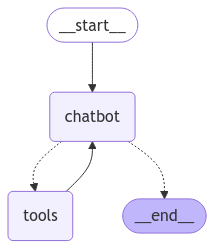

In [23]:
# Let's visualize the graph we've built. We'll use the same code as in the previous video.
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [25]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye',  'q']:
        print('Goodbye!')
        break
        
    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print('Assistant: ', value['messages'][-1].content)
        print('-' * 50)



User:  USA area is ...


Assistant:  
--------------------------------------------------
Assistant:  [{"url": "https://www.britannica.com/topic/largest-U-S-state-by-area", "content": "With an area of almost 3,800,000 square miles (9,840,000 square km), the United States is the fourth largest country in the world. Although its 50 states vary widely in size, one is by far the biggest: Alaska.At 665,384 square miles (1,723,337 square km), it is more than double the size of the second largest state, Texas, and more than 400 times the size of the smallest, Rhode Island."}, {"url": "https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_area", "content": "U.S. states by total area\nU.S. states by land area\nU.S. states by water area\nU.S. states by water percentage\nAlaska is the largest state by total area, land area, and water area.\n It is the seventh-largest country subdivision in the world.[4][failed verification]\nThe area of Alaska is 18% of the area of the United States and equivalent to 21% of

User:  qui


Assistant:  Bonjour ! Comment puis-je vous aider aujourd'hui ?
--------------------------------------------------


User:  quit


Goodbye!


##  Adding Memory to the Chatbot

In [ ]:
pip install -q langgraph-checkpoint-sqlite

In [21]:
# loading the API key form .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [37]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools.tavily_search import TavilySearchResults

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node('chatbot', chatbot)
tool_node = ToolNode(tools=[tool])
graph_builder.add_node('tools', tool_node)

graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition,
)

graph_builder.add_edge('tools', 'chatbot')
graph_builder.set_entry_point('chatbot')

In [38]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver ### fix

memory = SqliteSaver.from_conn_string(':memory:')
graph = graph_builder.compile(checkpointer=MemorySaver()) ### fix


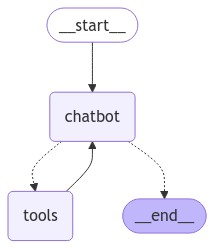

In [39]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
config = {'configurable': {'thread_id': '1'}}

In [41]:
prompt = 'What is the lastest AI model developed by OpenAI?'

# streaming the events. 
events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)

for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What is the lastest AI model developed by OpenAI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_Gp3mvbuTsWS9atCt3xMAg3vz)
 Call ID: call_Gp3mvbuTsWS9atCt3xMAg3vz
  Args:
    query: latest AI model developed by OpenAI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://techcrunch.com/2024/09/12/openai-unveils-a-model-that-can-fact-check-itself/", "content": "ChatGPT maker OpenAI has announced its next major product release: A generative AI model code-named Strawberry, officially called OpenAI o1. OpenAI o1 avoids some of the reasoning pitfalls that normally trip up generative AI models because it can effectively fact-check itself by spending more time considering all parts of a question. What makes o1 “feel” qualitatively different from other gen

In [42]:
# It has memory!
prompt = 'What about Google?'
events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What about Google?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_UpFkdcZvWoQPHxs6OvvZAmeh)
 Call ID: call_UpFkdcZvWoQPHxs6OvvZAmeh
  Args:
    query: latest AI model developed by Google
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://blog.google/technology/ai/google-gemini-ai/", "content": "This is a long-term commitment that requires building collaboratively, so we’re partnering with the industry and broader ecosystem on defining best practices and setting safety and security benchmarks through organizations like MLCommons, the Frontier Model Forum and its AI Safety Fund, and our Secure AI Framework (SAIF), which was designed to help mitigate security risks specific to AI systems across the public and private sectors. This is a significant 

In [33]:
prompt = 'What did I ask you so far?'

events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What did I ask you so far?
================================== Ai Message ==================================

So far, you have asked me the following questions:

1. What is the latest AI model developed by OpenAI?
2. What about Google?

If you have more questions or topics you'd like to discuss, feel free to let me know!


In [43]:
# NEW THREAD => no memory
config1 = {"configurable": {"thread_id": "10"}}

prompt = 'What did I ask you so far?'

events = graph.stream(
    {"messages": [("user", prompt)]}, config1, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

What did I ask you so far?
================================== Ai Message ==================================

You haven't asked me anything yet in this conversation. How can I assist you today?


In [44]:
snapshot = graph.get_state(config)
snapshot


StateSnapshot(values={'messages': [HumanMessage(content='What is the lastest AI model developed by OpenAI?', additional_kwargs={}, response_metadata={}, id='de7f95dd-7834-4278-af38-eb5f68977d9b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Gp3mvbuTsWS9atCt3xMAg3vz', 'function': {'arguments': '{"query":"latest AI model developed by OpenAI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 91, 'total_tokens': 115, 'completion_tokens_details': {'reasoning_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1bb46167f9', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-84c0aa34-f9f7-4288-97e9-dbc025601471-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI model developed by OpenAI'}, 'id': 'call_Gp3mvbuTsWS9atCt3xMAg3vz', 'type': 'tool_call'}], usage_metadata={'input_tokens': 91, 'output_t

In [45]:
snapshot.next

()